# 05 — Gaussian Mixture Models
### From Multimodal Density Estimation to the Expectation-Maximization Algorithm

---

> **Position in the series:**
> `01_statistical_learning_theory` → `02_pac_and_vc_dimensions` → `03_linear_algebra_and_geometry` → `04_pca` → **`05_gaussian_mixture_models`** → `06_linear_regression` → `07_logistic_regression` → `08_svm_and_kernel_methods`

## References

| # | Source |
|---|--------|
| [1] | C. M. Bishop — *Pattern Recognition and Machine Learning*, Springer, 2006 — Ch. 9 (Mixture Models and EM) |
| [2] | A. Ng — *CS229 Lecture Notes*, "Mixtures of Gaussians and the EM Algorithm" (cs229-notes7b), Stanford |
| [3] | A. Ng — *CS229 Lecture Notes*, "The EM Algorithm" (cs229-notes8, Jensen's Inequality derivation), Stanford |
| [4] | Iacopo Masi — *Clustering & Gaussian Mixture Models*, lecture slides & notebook, Sapienza SMIA (`05_clustering_GMM`) |
| [5] | T. Hastie, R. Tibshirani & J. Friedman — *The Elements of Statistical Learning*, 2nd ed., Springer, 2009 — §8.5, §14.3 |
| [6] | A. P. Dempster, N. M. Laird & D. B. Rubin — *Maximum Likelihood from Incomplete Data via the EM Algorithm*, JRSS B, 39(1), 1977 |
| [7] | K. P. Murphy — *Machine Learning: A Probabilistic Perspective*, MIT Press, 2012 — Ch. 11 |
| [8] | J. Bilmes — *A Gentle Tutorial of the EM Algorithm and its Application to Parameter Estimation for Gaussian Mixture and Hidden Markov Models*, ICSI TR-97-021, 1998 |

---

## Structure
1. Motivation: From a Single Gaussian to Multimodal Densities
2. Recap: The Multivariate Gaussian and Maximum Likelihood
3. The Gaussian Mixture Model: Definition and Generative Story
4. Latent Variables: The Complete-Data Formulation
5. Why Direct Maximum Likelihood Fails
6. The EM Algorithm I: Jensen's Inequality and the Evidence Lower Bound
7. The EM Algorithm II: E-Step — Posterior Responsibilities
8. The EM Algorithm III: M-Step — Closed-Form Updates for $\pi,\boldsymbol\mu,\boldsymbol\Sigma$
9. The Full EM Algorithm for GMM & Monotonic Convergence
10. Implementation From Scratch: Fitting a 2D GMM
11. Degenerate Solutions: Variance Collapse and Regularization
12. Relationship Between K-Means and GMM
13. Model Selection: Choosing $K$ with AIC/BIC
14. Covariance Types & Applications: Density Estimation, Sampling, Anomaly Detection

---
## 1. Motivation: From a Single Gaussian to Multimodal Densities

A single Gaussian $\mathcal N(\mu,\sigma^2)$ is a **unimodal** density: it has one peak and decays monotonically away from $\mu$. Its maximum-likelihood fit to data is just the sample mean and variance (Section 2). This is an excellent model whenever the data really is generated by one bump — but real data is very often **multi-modal**: it looks like it was generated by several distinct sub-populations mixed together (e.g. heights of men and women pooled together, pixel intensities of foreground vs. background, or clusters in feature space).

Fitting a single Gaussian to multi-modal data does not fail loudly — it silently returns the *global* mean and an inflated variance that straddles all the modes, badly under-fitting the true shape of the density. The example below makes this concrete: two well-separated 1-D clusters are pooled together, and the single-Gaussian MLE places its peak in the empty region between them.

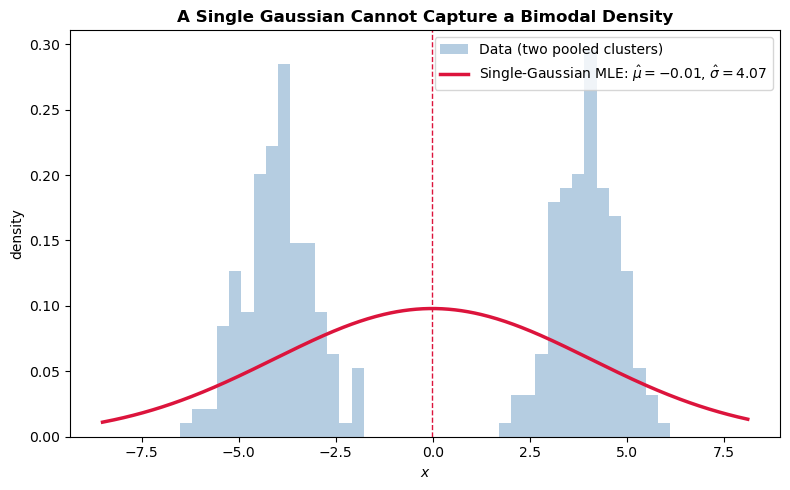

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(8)

# Two well-separated 1-D clusters, pooled into a single unlabeled sample
n = 300
data_a = np.random.normal(loc=-4.0, scale=0.8, size=n // 2)
data_b = np.random.normal(loc=4.0, scale=0.8, size=n // 2)
x = np.concatenate([data_a, data_b])

# MLE for a single Gaussian: sample mean and (biased) sample variance
mu_hat = x.mean()
var_hat = x.var()

grid = np.linspace(x.min() - 2, x.max() + 2, 400)
single_gaussian = (1.0 / np.sqrt(2 * np.pi * var_hat)) * np.exp(-0.5 * (grid - mu_hat) ** 2 / var_hat)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x, bins=40, density=True, alpha=0.4, color="steelblue", label="Data (two pooled clusters)")
ax.plot(grid, single_gaussian, color="crimson", lw=2.5,
        label=fr"Single-Gaussian MLE: $\hat\mu={mu_hat:.2f}$, $\hat\sigma={np.sqrt(var_hat):.2f}$")
ax.axvline(mu_hat, color="crimson", ls="--", lw=1)
ax.set_title("A Single Gaussian Cannot Capture a Bimodal Density", fontsize=12, fontweight="bold")
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Recap: The Multivariate Gaussian and Maximum Likelihood

For $\mathbf x\in\mathbb R^D$, the multivariate Gaussian density with mean $\boldsymbol\mu\in\mathbb R^D$ and covariance $\boldsymbol\Sigma\in\mathbb R^{D\times D}\;(\boldsymbol\Sigma\succ 0)$ is

$$
\mathcal N(\mathbf x\mid\boldsymbol\mu,\boldsymbol\Sigma)=\frac{1}{(2\pi)^{D/2}|\boldsymbol\Sigma|^{1/2}}\exp\!\left(-\tfrac12(\mathbf x-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf x-\boldsymbol\mu)\right).
$$

The exponent $(\mathbf x-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf x-\boldsymbol\mu)$ is the squared **Mahalanobis distance**: it measures distance from $\boldsymbol\mu$ in units of standard deviation *along the principal axes of* $\boldsymbol\Sigma$, so the level sets $\{\mathbf x : (\mathbf x-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf x-\boldsymbol\mu)=c\}$ are ellipses whose axes are the eigenvectors of $\boldsymbol\Sigma$ with radii $\propto\sqrt{\text{eigenvalue}}$.

### MLE for a Single Gaussian

Given i.i.d. samples $\{\mathbf x_n\}_{n=1}^N$, the log-likelihood is

$$
\ln p(\mathbf X\mid\boldsymbol\mu,\boldsymbol\Sigma)=-\frac{ND}{2}\ln(2\pi)-\frac N2\ln|\boldsymbol\Sigma|-\frac12\sum_{n=1}^N(\mathbf x_n-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf x_n-\boldsymbol\mu).
$$

Setting $\nabla_{\boldsymbol\mu}=\boldsymbol\Sigma^{-1}\sum_n(\mathbf x_n-\boldsymbol\mu)=\mathbf 0$ gives the sample mean. Using the trace identity $(\mathbf x-\boldsymbol\mu)^\top\mathbf A(\mathbf x-\boldsymbol\mu)=\operatorname{tr}\!\big(\mathbf A(\mathbf x-\boldsymbol\mu)(\mathbf x-\boldsymbol\mu)^\top\big)$ and $\partial\ln|\boldsymbol\Sigma^{-1}|/\partial\boldsymbol\Sigma^{-1}=\boldsymbol\Sigma$, differentiating w.r.t. $\boldsymbol\Sigma^{-1}$ and setting to zero gives:

$$
\boxed{\;\hat{\boldsymbol\mu}=\frac1N\sum_{n=1}^N\mathbf x_n\,,\qquad \hat{\boldsymbol\Sigma}=\frac1N\sum_{n=1}^N(\mathbf x_n-\hat{\boldsymbol\mu})(\mathbf x_n-\hat{\boldsymbol\mu})^\top\;}
$$

— exactly the sample mean and (biased) sample covariance. This closed form is the reason a *single* Gaussian is so easy to fit, and it is exactly what breaks down for mixtures (Section 5).

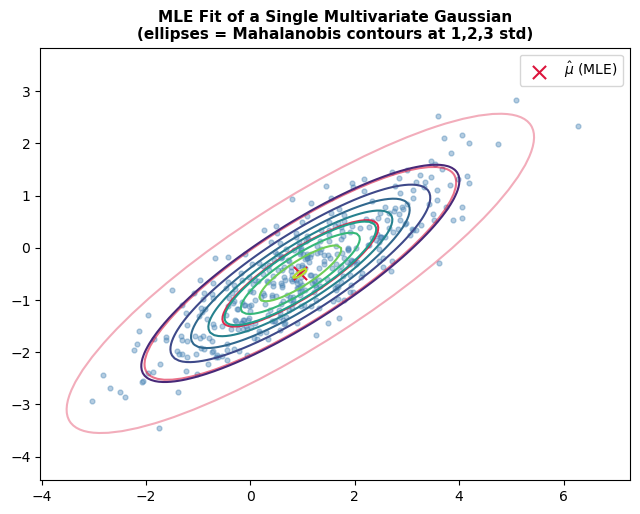

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf(X, mu, cov):
    # N(X | mu, cov), X: (N,D), mu: (D,), cov: (D,D). Returns (N,).
    D = mu.shape[0]
    diff = X - mu
    cov_inv = np.linalg.inv(cov)
    sign, logdet = np.linalg.slogdet(cov)
    quad = np.einsum('ni,ij,nj->n', diff, cov_inv, diff)
    log_norm = -0.5 * (D * np.log(2 * np.pi) + logdet)
    return np.exp(log_norm - 0.5 * quad)

def cov_ellipse(mu, cov, n_std=2.0, **kwargs):
    # Return a matplotlib Ellipse patch for the n_std contour of N(mu, cov).
    from matplotlib.patches import Ellipse
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    return Ellipse(xy=mu, width=width, height=height, angle=angle, **kwargs)

np.random.seed(8)
mu_true = np.array([1.0, -0.5])
cov_true = np.array([[2.0, 1.2], [1.2, 1.0]])
X_demo = np.random.multivariate_normal(mu_true, cov_true, size=400)
mu_hat = X_demo.mean(axis=0)
cov_hat = np.cov(X_demo.T, bias=True)

xx, yy = np.meshgrid(np.linspace(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1, 150),
                      np.linspace(X_demo[:, 1].min() - 1, X_demo[:, 1].max() + 1, 150))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = gaussian_pdf(grid, mu_hat, cov_hat).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X_demo[:, 0], X_demo[:, 1], s=12, alpha=0.4, color="steelblue")
ax.contour(xx, yy, zz, levels=8, cmap="viridis")
for n_std, alpha in zip([1, 2, 3], [0.9, 0.6, 0.35]):
    ax.add_patch(cov_ellipse(mu_hat, cov_hat, n_std=n_std, fill=False, edgecolor="crimson", lw=1.5, alpha=alpha))
ax.scatter(*mu_hat, color="crimson", marker="x", s=90, label=r"$\hat\mu$ (MLE)")
ax.set_title("MLE Fit of a Single Multivariate Gaussian\n(ellipses = Mahalanobis contours at 1,2,3 std)", fontsize=11, fontweight="bold")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## 3. The Gaussian Mixture Model: Definition and Generative Story

A **Gaussian Mixture Model (GMM)** with $K$ components models the density of $\mathbf x$ as a convex combination of $K$ Gaussians:

$$
p(\mathbf x\mid\boldsymbol\pi,\{\boldsymbol\mu_k,\boldsymbol\Sigma_k\})=\sum_{k=1}^K\pi_k\,\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k),\qquad \pi_k\ge0,\quad\sum_{k=1}^K\pi_k=1.
$$

The **mixing coefficients** $\pi_k$ can be read as the prior probability that a data point was generated by component $k$. This is a strictly richer model class than a single Gaussian: with enough components a GMM can approximate *any* smooth density arbitrarily well (it is a universal density approximator), while remaining fully parametric and differentiable.

### Generative Story

The mixture form above is exactly what you get by marginalizing out a discrete choice: to draw a sample,
1. Pick a component $k\sim\text{Categorical}(\pi_1,\dots,\pi_K)$.
2. Draw $\mathbf x\sim\mathcal N(\boldsymbol\mu_k,\boldsymbol\Sigma_k)$.

This two-step process is made precise with a latent variable in Section 4. Below we build a ground-truth 2-D, 3-component GMM, sample from it, and use this synthetic dataset for the rest of the notebook — this way we always know the "true" parameters the EM algorithm is trying to recover.

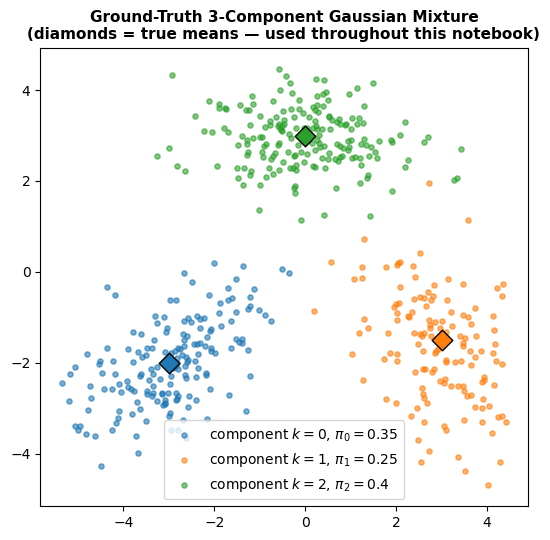

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sample_gmm(n_samples, pi, mu, cov, rng):
    K = len(pi)
    z = rng.choice(K, size=n_samples, p=pi)
    X = np.array([rng.multivariate_normal(mu[k], cov[k]) for k in z])
    return X, z

rng = np.random.default_rng(8)

pi_true = np.array([0.35, 0.25, 0.40])
mu_true = np.array([[-3.0, -2.0], [3.0, -1.5], [0.0, 3.0]])
cov_true = np.array([
    [[1.2, 0.5], [0.5, 0.8]],
    [[0.7, -0.3], [-0.3, 1.3]],
    [[1.5, 0.0], [0.0, 0.4]],
])

X, z_true = sample_gmm(500, pi_true, mu_true, cov_true, rng)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
colors = ["tab:blue", "tab:orange", "tab:green"]
for k in range(3):
    ax.scatter(X[z_true == k, 0], X[z_true == k, 1], s=14, alpha=0.6, color=colors[k], label=fr"component $k={k}$, $\pi_{k}={pi_true[k]}$")
    ax.scatter(*mu_true[k], color=colors[k], edgecolor="black", marker="D", s=110, zorder=5)
ax.set_title("Ground-Truth 3-Component Gaussian Mixture\n(diamonds = true means — used throughout this notebook)", fontsize=11, fontweight="bold")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## 4. Latent Variables: The Complete-Data Formulation

Introduce a **latent variable** $\mathbf z\in\{0,1\}^K$ using a 1-of-$K$ (one-hot) encoding: $z_k=1$ means "this point was generated by component $k$", and $\sum_k z_k=1$. Define

$$
p(z_k=1)=\pi_k \qquad\Longleftrightarrow\qquad p(\mathbf z)=\prod_{k=1}^K\pi_k^{z_k},
$$
$$
p(\mathbf x\mid z_k=1)=\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)\qquad\Longleftrightarrow\qquad p(\mathbf x\mid\mathbf z)=\prod_{k=1}^K\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)^{z_k}.
$$

**Marginalizing out $\mathbf z$ recovers exactly the mixture density of Section 3:**

$$
p(\mathbf x)=\sum_{\mathbf z}p(\mathbf z)\,p(\mathbf x\mid\mathbf z)=\sum_{k=1}^K\pi_k\,\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k).
$$

So $\mathbf z$ is nothing but the *unobserved cluster label* — in the notation of CS229, $\mathbf x^{(i)}$ is observed but $z^{(i)}\in\{1,\dots,K\}$ is not. If we *did* observe the labels $z^{(i)}$, fitting the model would be trivial: split the data by label and apply the single-Gaussian MLE of Section 2 to each group, and set $\hat\pi_k$ to the fraction of points with label $k$. The **complete-data log-likelihood** — i.e. the log-likelihood we *would* maximize if $\mathbf z$ were observed — is

$$
\ln p(\mathbf X,\mathbf Z\mid\boldsymbol\pi,\boldsymbol\mu,\boldsymbol\Sigma)=\sum_{n=1}^N\sum_{k=1}^K z_{nk}\Big[\ln\pi_k+\ln\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)\Big].
$$

The entire difficulty of fitting a GMM is that $\mathbf Z$ is **not** observed — Sections 6–8 build the algorithm (EM) that handles exactly this situation.

---
## 5. Why Direct Maximum Likelihood Fails

Marginalizing $\mathbf z$ analytically out of the log-likelihood gives

$$
\ln p(\mathbf X\mid\boldsymbol\pi,\boldsymbol\mu,\boldsymbol\Sigma)=\sum_{n=1}^N\ln\left(\sum_{k=1}^K\pi_k\,\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)\right).
$$

Compare this to the single-Gaussian case (Section 2): there, the log of a Gaussian is a nice quadratic, so setting gradients to zero gives closed-form updates. Here we have a **log of a sum**, and the log can no longer be pushed inside to cancel the $\exp(\cdot)$ in each Gaussian. Differentiating w.r.t. $\boldsymbol\mu_k$ gives

$$
\frac{\partial}{\partial\boldsymbol\mu_k}\ln p(\mathbf X\mid\theta)=\sum_{n=1}^N\underbrace{\frac{\pi_k\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)}{\sum_j\pi_j\mathcal N(\mathbf x_n\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)}}_{\text{depends on }\boldsymbol\mu_k,\boldsymbol\Sigma_k,\pi_k\text{ themselves!}}\boldsymbol\Sigma_k^{-1}(\mathbf x_n-\boldsymbol\mu_k)=\mathbf 0.
$$

Setting this to zero does *not* give a closed-form solution: $\boldsymbol\mu_k$ appears both outside and **inside** the fraction (through every Gaussian in the denominator, since all $K$ components are coupled by the shared normalization). This fixed-point structure —

$$
\boldsymbol\mu_k=\frac{\sum_n \gamma_{nk}\,\mathbf x_n}{\sum_n \gamma_{nk}},\qquad \gamma_{nk}:=\frac{\pi_k\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)}{\sum_j\pi_j\mathcal N(\mathbf x_n\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)}
$$

— is exactly what the **EM algorithm** exploits: treat $\gamma_{nk}$ as fixed (computed from the *current* parameters), solve the now-closed-form update for $\boldsymbol\mu_k,\boldsymbol\Sigma_k,\pi_k$, then recompute $\gamma_{nk}$, and iterate. Sections 6–9 derive this rigorously and show *why* iterating this way is guaranteed to never decrease the likelihood.

A second, more severe problem is that $\ln p(\mathbf X\mid\theta)$ is **unbounded above**: as a component's mean approaches a single data point and its covariance shrinks to a point mass, its density there diverges. This *singularity* is unique to mixtures (it cannot happen for a single Gaussian, Section 2) and is treated in Section 11.

---
## 6. The EM Algorithm I: Jensen's Inequality and the Evidence Lower Bound

We now derive EM in general form, following the CS229 (Ng, notes8) construction, then specialize it to the GMM. For each data point $\mathbf x^{(i)}$ let $Q_i$ be *any* probability distribution over the latent label ($\sum_{z}Q_i(z)=1$, $Q_i(z)\ge0$). Rewrite the log-likelihood by multiplying and dividing by $Q_i$:

$$
\ell(\theta)=\sum_{i=1}^N\ln p(\mathbf x^{(i)}\mid\theta)=\sum_{i=1}^N\ln\sum_{z}p(\mathbf x^{(i)},z\mid\theta)=\sum_{i=1}^N\ln\sum_{z}Q_i(z)\,\frac{p(\mathbf x^{(i)},z\mid\theta)}{Q_i(z)}.
$$

The inner sum is an **expectation** over $z\sim Q_i$ of the ratio $p(\mathbf x^{(i)},z\mid\theta)/Q_i(z)$. Since $\ln(\cdot)$ is **concave**, Jensen's inequality gives $\ln\mathbb E[\cdot]\ge\mathbb E[\ln(\cdot)]$, hence

$$
\ell(\theta)\;\ge\;\underbrace{\sum_{i=1}^N\sum_{z}Q_i(z)\ln\frac{p(\mathbf x^{(i)},z\mid\theta)}{Q_i(z)}}_{\displaystyle =:\,\mathrm{ELBO}(Q,\theta)}\qquad\text{for \emph{any} choice of }\{Q_i\}.
$$

$\mathrm{ELBO}$ (Evidence Lower BOund) is a lower bound on the true log-likelihood for **any** valid $Q_i$, and it is far easier to work with because the log is now *outside* the sum over $z$ but *inside* is a plain product $p(\mathbf x,z\mid\theta)=p(z\mid\theta)p(\mathbf x\mid z,\theta)$ — no more log-of-sum.

**Equality (tightness).** Jensen's inequality is tight exactly when the argument of $\ln(\cdot)$ is constant over the randomness, i.e. $p(\mathbf x^{(i)},z\mid\theta)/Q_i(z)=c$ for all $z$. Since $Q_i$ must sum to 1, this forces

$$
Q_i(z)=\frac{p(\mathbf x^{(i)},z\mid\theta)}{\sum_{z'}p(\mathbf x^{(i)},z'\mid\theta)}=p(z\mid \mathbf x^{(i)},\theta),
$$

i.e. **the tight choice of $Q_i$ is the true posterior over the latent variable given the current parameters.** This single fact generates the whole algorithm:

* **E-step:** fix $\theta=\theta^{\text{old}}$ and set $Q_i(z)=p(z\mid\mathbf x^{(i)},\theta^{\text{old}})$ — this makes $\mathrm{ELBO}(Q,\theta^{\text{old}})=\ell(\theta^{\text{old}})$ exactly (the bound touches the true likelihood at the current point).
* **M-step:** with $Q_i$ now fixed, maximize $\mathrm{ELBO}(Q,\theta)$ over $\theta$. Because $\ell(\theta)\ge\mathrm{ELBO}(Q,\theta)$ everywhere and the two agree at $\theta^{\text{old}}$, any $\theta^{\text{new}}$ that increases the ELBO also increases (or at worst does not decrease) the true log-likelihood — this is the convergence argument, made precise in Section 9.

For a GMM, $z\in\{1,\dots,K\}$ is the mixture-component index, $p(z=k\mid\theta)=\pi_k$, and $p(\mathbf x\mid z=k,\theta)=\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)$. Sections 7–8 spell out exactly what $Q_i$ (E-step) and the ELBO maximizer (M-step) look like in this case.

---
## 7. The EM Algorithm II: E-Step — Posterior Responsibilities

From Section 6, the E-step sets $Q_i(z_k)=p(z_k=1\mid\mathbf x_n,\theta^{\text{old}})$. By Bayes' rule this **responsibility**, denoted $\gamma_{nk}$, is

$$
\gamma_{nk}:=p(z_{nk}=1\mid\mathbf x_n)=\frac{p(z_{nk}=1)\,p(\mathbf x_n\mid z_{nk}=1)}{\sum_{j=1}^K p(z_{nj}=1)\,p(\mathbf x_n\mid z_{nj}=1)}=\frac{\pi_k\,\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)}{\sum_{j=1}^K\pi_j\,\mathcal N(\mathbf x_n\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)}.
$$

$\gamma_{nk}\in[0,1]$ is the **soft** (probabilistic) assignment of point $n$ to component $k$, and $\sum_k\gamma_{nk}=1$ for every $n$ — this is the key difference from K-means' *hard* 0/1 assignment (Section 12). Numerically, computing this ratio directly can overflow/underflow because $\mathcal N(\cdot)$ involves $\exp$ of possibly large negative numbers; the standard fix is to work in log-space and use the **log-sum-exp** trick:

$$
\log\gamma_{nk}=\big(\ln\pi_k+\ln\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)\big)-\operatorname{logsumexp}_j\big(\ln\pi_j+\ln\mathcal N(\mathbf x_n\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)\big),
$$
$$
\operatorname{logsumexp}_j(a_j):=a_{\max}+\ln\sum_j\exp(a_j-a_{\max}),\qquad a_{\max}=\max_j a_j.
$$

This also gives the per-point log-likelihood for free: $\ln p(\mathbf x_n)=\operatorname{logsumexp}_k(\ln\pi_k+\ln\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k))$, so the E-step and the log-likelihood evaluation (needed for the convergence check in Section 9) share the same computation.

In [4]:
import numpy as np

def logsumexp(a, axis=None):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    return np.squeeze(out, axis=axis) if axis is not None else out.item()

def log_gaussian_pdf(X, mu, cov):
    # log N(X | mu, cov). X: (N,D). Returns (N,).
    D = mu.shape[0]
    diff = X - mu
    cov_inv = np.linalg.inv(cov)
    _, logdet = np.linalg.slogdet(cov)
    quad = np.einsum('ni,ij,nj->n', diff, cov_inv, diff)
    return -0.5 * (D * np.log(2 * np.pi) + logdet + quad)

def e_step(X, pi, mu, cov):
    # Returns responsibilities gamma (N,K) and total log-likelihood (scalar).
    N, K = X.shape[0], len(pi)
    log_weighted = np.zeros((N, K))
    for k in range(K):
        log_weighted[:, k] = np.log(pi[k]) + log_gaussian_pdf(X, mu[k], cov[k])
    log_norm = logsumexp(log_weighted, axis=1)          # (N,)
    log_gamma = log_weighted - log_norm[:, None]
    gamma = np.exp(log_gamma)
    total_log_likelihood = log_norm.sum()
    return gamma, total_log_likelihood

def score_samples(X, pi, mu, cov):
    # Per-point log-density log p(x_n) under the mixture -- used for density
    # estimation and anomaly detection in Section 14.
    K = len(pi)
    log_weighted = np.column_stack([np.log(pi[k]) + log_gaussian_pdf(X, mu[k], cov[k]) for k in range(K)])
    return logsumexp(log_weighted, axis=1)

# Sanity check: responsibilities computed at the *true* parameters should sum to 1
# per row and roughly recover the ground-truth labels of Section 3.
gamma_check, ll_check = e_step(X, pi_true, mu_true, cov_true)
print("row sums (should all be 1.0):", np.allclose(gamma_check.sum(axis=1), 1.0))
print("log-likelihood at the TRUE parameters:", ll_check)
print("hard assignment via argmax(gamma) matches true z for "
      f"{(gamma_check.argmax(axis=1) == z_true).mean()*100:.1f}% of points")

row sums (should all be 1.0): True
log-likelihood at the TRUE parameters: -1870.6359031416841
hard assignment via argmax(gamma) matches true z for 99.4% of points


---
## 8. The EM Algorithm III: M-Step — Closed-Form Updates for $\pi,\boldsymbol\mu,\boldsymbol\Sigma$

With the responsibilities $\gamma_{nk}$ fixed from the E-step, Section 6 tells us to maximize the ELBO over $\theta$, which (dropping the $-\sum Q_i\ln Q_i$ entropy term that does not depend on $\theta$) reduces to maximizing the **expected complete-data log-likelihood**:

$$
Q(\theta,\theta^{\text{old}})=\sum_{n=1}^N\sum_{k=1}^K\gamma_{nk}\Big[\ln\pi_k+\ln\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)\Big].
$$

Define $N_k:=\sum_{n=1}^N\gamma_{nk}$ — the *effective* (soft) number of points assigned to component $k$, with $\sum_k N_k=N$.

**Update for $\boldsymbol\mu_k$.** Only the Gaussian term depends on $\boldsymbol\mu_k$; using the single-Gaussian gradient of Section 2 weighted by $\gamma_{nk}$:

$$
\frac{\partial Q}{\partial\boldsymbol\mu_k}=\sum_n\gamma_{nk}\,\boldsymbol\Sigma_k^{-1}(\mathbf x_n-\boldsymbol\mu_k)=\mathbf 0\;\;\Longrightarrow\;\;\boxed{\boldsymbol\mu_k=\frac{1}{N_k}\sum_{n=1}^N\gamma_{nk}\,\mathbf x_n}
$$

— a $\gamma$-weighted mean, exactly the fixed-point form anticipated in Section 5.

**Update for $\boldsymbol\Sigma_k$.** Using the same trace identity as Section 2, weighted by $\gamma_{nk}$, and differentiating w.r.t. $\boldsymbol\Sigma_k^{-1}$:

$$
\boxed{\boldsymbol\Sigma_k=\frac{1}{N_k}\sum_{n=1}^N\gamma_{nk}\,(\mathbf x_n-\boldsymbol\mu_k)(\mathbf x_n-\boldsymbol\mu_k)^\top}
$$

— a $\gamma$-weighted covariance, using the **already updated** $\boldsymbol\mu_k$.

**Update for $\boldsymbol\pi$.** The $\pi_k$ terms only appear as $\sum_{n,k}\gamma_{nk}\ln\pi_k=\sum_k N_k\ln\pi_k$, to be maximized subject to $\sum_k\pi_k=1$. Introduce a Lagrange multiplier $\lambda$:

$$
\mathcal L=\sum_k N_k\ln\pi_k+\lambda\Big(\sum_k\pi_k-1\Big)\;\Longrightarrow\;\frac{\partial\mathcal L}{\partial\pi_k}=\frac{N_k}{\pi_k}+\lambda=0\;\Longrightarrow\;\pi_k=-\frac{N_k}{\lambda}.
$$

Summing over $k$: $1=\sum_k\pi_k=-\frac1\lambda\sum_kN_k=-\frac N\lambda\Rightarrow\lambda=-N$. Substituting back:

$$
\boxed{\pi_k=\frac{N_k}{N}}
$$

— simply the (soft) fraction of points assigned to component $k$. All three updates are closed form **given** $\gamma_{nk}$ — exactly the fixed point that Section 5 could not solve directly, now solvable because the E-step decouples the components.

In [5]:
import numpy as np

def m_step(X, gamma, reg_covar=1e-6):
    # Closed-form M-step. gamma: (N,K). reg_covar added to the diagonal for stability (Section 11).
    N, D = X.shape
    K = gamma.shape[1]
    Nk = gamma.sum(axis=0)                      # (K,)
    pi = Nk / N
    mu = (gamma.T @ X) / Nk[:, None]             # (K,D)
    cov = np.zeros((K, D, D))
    for k in range(K):
        diff = X - mu[k]                         # (N,D)
        weighted_diff = diff * gamma[:, k:k + 1]
        cov[k] = (weighted_diff.T @ diff) / Nk[k] + reg_covar * np.eye(D)
    return pi, mu, cov

# Sanity check: one E-step + M-step starting from the TRUE parameters
# should return (approximately) the same parameters -- a fixed point.
gamma0, _ = e_step(X, pi_true, mu_true, cov_true)
pi1, mu1, cov1 = m_step(X, gamma0)
print("pi  (updated):", np.round(pi1, 3), " vs true:", pi_true)
print("mu[0] (updated):", np.round(mu1[0], 2), " vs true:", mu_true[0])

pi  (updated): [0.347 0.272 0.381]  vs true: [0.35 0.25 0.4 ]
mu[0] (updated): [-2.93 -1.97]  vs true: [-3. -2.]


---
## 9. The Full EM Algorithm for GMM & Monotonic Convergence

Putting Sections 7–8 together:

> **EM for GMM**
> 1. **Initialize** $\pi_k,\boldsymbol\mu_k,\boldsymbol\Sigma_k$ (e.g. $\boldsymbol\mu_k$ = $K$ random data points, $\boldsymbol\Sigma_k=\mathbf I$, $\pi_k=1/K$).
> 2. **E-step:** compute responsibilities $\gamma_{nk}$ and the log-likelihood $\ell(\theta)$ (Section 7).
> 3. **M-step:** update $\pi_k,\boldsymbol\mu_k,\boldsymbol\Sigma_k$ in closed form using $\gamma_{nk}$ (Section 8).
> 4. **Repeat** steps 2–3 until $\ell(\theta)$ stops improving (e.g. $|\ell^{(t+1)}-\ell^{(t)}|<\varepsilon$).

### Why the Log-Likelihood Never Decreases

Chaining the two inequalities from Section 6:

$$
\ell(\theta^{(t+1)})\;\ge\;\mathrm{ELBO}(Q^{(t)},\theta^{(t+1)})\;\ge\;\mathrm{ELBO}(Q^{(t)},\theta^{(t)})\;=\;\ell(\theta^{(t)}).
$$

* The first inequality holds because $\mathrm{ELBO}$ is a lower bound on $\ell$ for **any** parameters (Jensen, Section 6) — in particular at $\theta^{(t+1)}$.
* The second inequality holds because the M-step **chooses** $\theta^{(t+1)}=\arg\max_\theta\mathrm{ELBO}(Q^{(t)},\theta)$, so it cannot do worse than staying at $\theta^{(t)}$.
* The equality holds because the E-step made the bound **tight** at $\theta^{(t)}$ (Section 6).

Hence $\ell(\theta^{(t+1)})\ge\ell(\theta^{(t)})$ at every iteration: EM performs **monotonic, non-decreasing** ascent on the true (incomplete-data) log-likelihood, even though it never has to touch the intractable log-of-a-sum directly. (It is only guaranteed to reach a local — not global — maximum, and is sensitive to initialization; see Section 11.)

In [6]:
import numpy as np

def em_gmm(X, K, n_iter=100, tol=1e-6, reg_covar=1e-6, rng=None, verbose=False):
    rng = np.random.default_rng() if rng is None else rng
    N, D = X.shape

    # Initialization: means = K random data points, identity covariances, uniform pi
    idx = rng.choice(N, size=K, replace=False)
    mu = X[idx].copy()
    cov = np.array([np.eye(D) for _ in range(K)])
    pi = np.full(K, 1.0 / K)

    history = []
    for it in range(n_iter):
        gamma, ll = e_step(X, pi, mu, cov)
        history.append(ll)
        if verbose:
            print(f"iter {it:3d}  log-likelihood = {ll:.4f}")
        pi, mu, cov = m_step(X, gamma, reg_covar=reg_covar)
        if it > 0 and abs(history[-1] - history[-2]) < tol:
            break
    gamma, ll = e_step(X, pi, mu, cov)
    history.append(ll)
    return {"pi": pi, "mu": mu, "cov": cov, "gamma": gamma, "history": np.array(history)}

rng = np.random.default_rng(42)
result = em_gmm(X, K=3, rng=rng, verbose=False)
print("Converged in", len(result["history"]), "E/M sweeps")
print("Recovered pi:", np.round(result["pi"], 3))
print("Log-likelihood strictly increasing (monotonic)?",
      np.all(np.diff(result["history"]) >= -1e-8))

Converged in 15 E/M sweeps
Recovered pi: [0.272 0.346 0.381]
Log-likelihood strictly increasing (monotonic)? True


---
## 10. Implementation From Scratch: Fitting a 2D GMM

We now watch EM run on the synthetic dataset of Section 3, tracking three things at once: (i) the monotonic increase of the log-likelihood guaranteed by Section 9, (ii) the covariance ellipses converging towards the ground truth, and (iii) the recovered parameters vs. the true generating parameters.

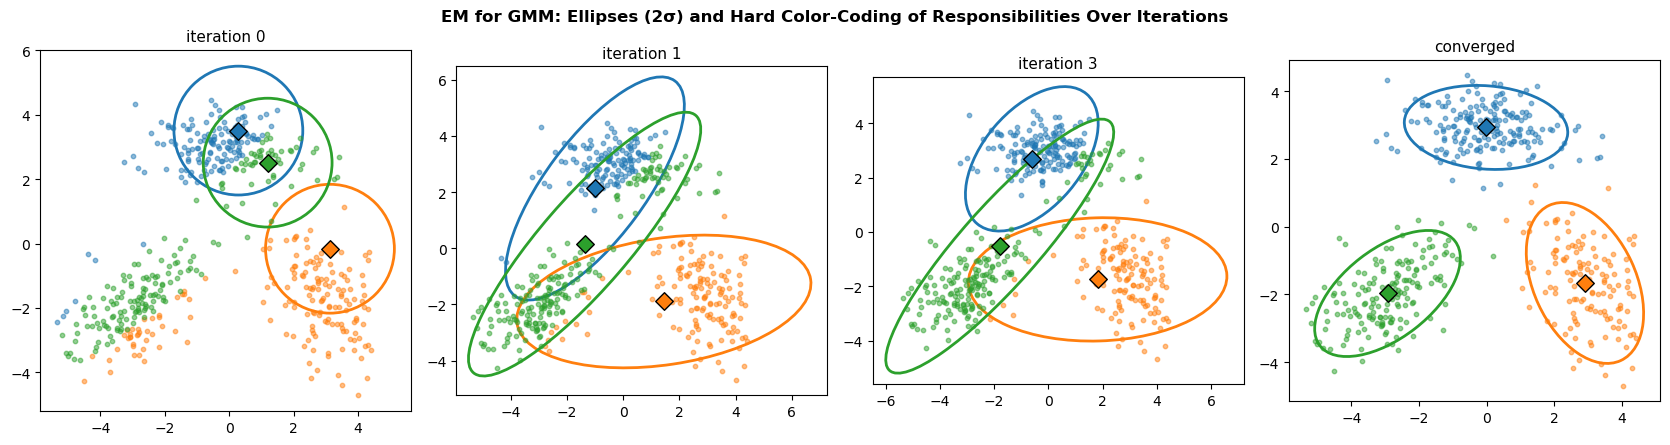

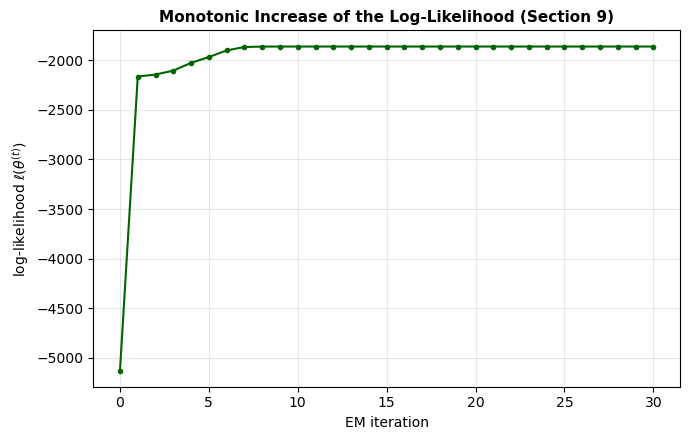

Recovered vs. true mixing weights (order may permute):
  pi recovered: [0.272 0.346 0.381]
  pi true     : [0.25 0.35 0.4 ]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def em_gmm_with_snapshots(X, K, n_iter, rng, reg_covar=1e-6, snapshot_iters=()):
    N, D = X.shape
    idx = rng.choice(N, size=K, replace=False)
    mu, cov, pi = X[idx].copy(), np.array([np.eye(D) for _ in range(K)]), np.full(K, 1.0 / K)
    history, snapshots = [], {}
    for it in range(n_iter):
        gamma, ll = e_step(X, pi, mu, cov)
        history.append(ll)
        if it in snapshot_iters:
            snapshots[it] = (pi.copy(), mu.copy(), cov.copy(), gamma.copy())
        pi, mu, cov = m_step(X, gamma, reg_covar=reg_covar)
    gamma, ll = e_step(X, pi, mu, cov)
    history.append(ll)
    snapshots["final"] = (pi.copy(), mu.copy(), cov.copy(), gamma.copy())
    return np.array(history), snapshots

rng = np.random.default_rng(3)
snap_at = (0, 1, 3)
history, snaps = em_gmm_with_snapshots(X, K=3, n_iter=30, rng=rng, snapshot_iters=snap_at)

panels = list(snap_at) + ["final"]
fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.3))
for ax, key in zip(axes, panels):
    pi_s, mu_s, cov_s, gamma_s = snaps[key]
    hard = gamma_s.argmax(axis=1)
    for k in range(3):
        ax.scatter(X[hard == k, 0], X[hard == k, 1], s=10, alpha=0.5, color=colors[k])
        ax.add_patch(cov_ellipse(mu_s[k], cov_s[k], n_std=2, fill=False, edgecolor=colors[k], lw=2))
        ax.scatter(*mu_s[k], color=colors[k], edgecolor="black", marker="D", s=80, zorder=5)
    ax.set_title(f"iteration {key}" if key != "final" else "converged", fontsize=11)
    ax.set_aspect("equal")
plt.suptitle("EM for GMM: Ellipses (2σ) and Hard Color-Coding of Responsibilities Over Iterations", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history, marker="o", ms=3, color="darkgreen")
ax.set_xlabel("EM iteration")
ax.set_ylabel(r"log-likelihood $\ell(\theta^{(t)})$")
ax.set_title("Monotonic Increase of the Log-Likelihood (Section 9)", fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Recovered vs. true mixing weights (order may permute):")
print("  pi recovered:", np.round(np.sort(snaps['final'][0]), 3))
print("  pi true     :", np.round(np.sort(pi_true), 3))

---
## 11. Degenerate Solutions: Variance Collapse and Regularization

Recall from Section 5 that $\ell(\theta)$ is unbounded above. Concretely: suppose component $k$'s mean collapses onto a single data point, $\boldsymbol\mu_k\to\mathbf x_m$, while its covariance shrinks, $\boldsymbol\Sigma_k\to\varepsilon\mathbf I$ with $\varepsilon\to0^+$. Then

$$
\mathcal N(\mathbf x_m\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)=\frac{1}{(2\pi\varepsilon)^{D/2}}\xrightarrow[\varepsilon\to0]{}\infty,
$$

so $\ell(\theta)\to\infty$: a **global maximum does not exist** for the raw GMM likelihood — the true global optimum is this useless "spike" that fits one point perfectly and ignores everything else. This never happens for a single Gaussian (Section 2), because with only one component the mean is forced to average *all* the data (it can't isolate a single point while leaving the rest unexplained); with $K\ge2$ components, one component is always free to specialize in a lone point while the others explain the rest.

In practice this shows up as: a cluster with very few effective points $N_k$, whose $\boldsymbol\Sigma_k$ becomes near-singular, causing `log|Σ_k| → -∞` and the log-likelihood to diverge upward. Two standard, complementary fixes:

1. **Covariance regularization** (what `m_step` above already does via `reg_covar`): add a small $\varepsilon\mathbf I$ to every $\boldsymbol\Sigma_k$ at each M-step, which lower-bounds its eigenvalues and prevents the determinant from vanishing. This is a mild form of MAP estimation (an implicit inverse-Wishart prior).
2. **Component monitoring**: if $N_k$ collapses towards 0, re-initialize that component at a random data point (or the point with lowest current likelihood) rather than let it decay further.

In practice the danger is greatest when the model is **over-parameterized** — more components than there are real clusters, or too little data for the chosen $K$ (motivating the model-selection tools of Section 13). The cell below reproduces this exactly: we fit $K=4$ components to the $K{=}3$-cluster dataset of Section 3, with one component deliberately seeded tight on a single point. The three "real" clusters keep the other three components well-behaved, leaving the fourth, spare component free to specialize on its single seed point with nothing to compete against.

In [8]:
import numpy as np

def em_gmm_seeded(X, K, seed_idx, n_iter, reg_covar, seed_scale=1e-3, other_scale=2.0):
    N, D = X.shape
    mu = X[seed_idx].copy()
    # Component 0 seeded pathologically tight; the rest start broad and normal.
    cov = np.array([np.eye(D) * seed_scale] + [np.eye(D) * other_scale for _ in range(K - 1)])
    pi = np.full(K, 1.0 / K)
    history, min_eig = [], []
    for it in range(n_iter):
        try:
            gamma, ll = e_step(X, pi, mu, cov)
        except np.linalg.LinAlgError:
            print(f"  reg_covar={reg_covar}: Sigma_0 became numerically singular at iteration {it}"
                  " -- the E-step can no longer even be evaluated (1/|Sigma| = inf).")
            break
        history.append(ll)
        min_eig.append(np.linalg.eigvalsh(cov[0]).min())
        pi, mu, cov = m_step(X, gamma, reg_covar=reg_covar)
    return np.array(history), np.array(min_eig)

seed_idx = [7, 50, 150, 300]   # component 0 seeded exactly on data point X[7]
print("Without regularization (reg_covar = 0):")
ll_collapse, eig_collapse = em_gmm_seeded(X, K=4, seed_idx=seed_idx, n_iter=40, reg_covar=0.0)
for it in range(len(ll_collapse)):
    print(f"  iter {it}: log-likelihood={ll_collapse[it]:.2f}, min-eig(Sigma_0)={eig_collapse[it]:.2e}")

print("\nWith regularization (reg_covar = 1e-2):")
ll_stable, eig_stable = em_gmm_seeded(X, K=4, seed_idx=seed_idx, n_iter=40, reg_covar=1e-2)
for it in [0, 1, 5, 10, 39]:
    print(f"  iter {it}: log-likelihood={ll_stable[it]:.2f}, min-eig(Sigma_0)={eig_stable[it]:.2e}")
print("\n-> Unregularized: Sigma_0's eigenvalue collapses to ~0 in a couple of sweeps and the")
print("   algorithm breaks (the exact degeneracy of Section 11). Regularized: the eigenvalue")
print("   is floored at reg_covar and EM converges to a normal, stable solution instead.")

Without regularization (reg_covar = 0):
  reg_covar=0.0: Sigma_0 became numerically singular at iteration 2 -- the E-step can no longer even be evaluated (1/|Sigma| = inf).
  iter 0: log-likelihood=-2353.26, min-eig(Sigma_0)=1.00e-03
  iter 1: log-likelihood=-1833.95, min-eig(Sigma_0)=1.67e-32

With regularization (reg_covar = 1e-2):
  iter 0: log-likelihood=-2353.26, min-eig(Sigma_0)=1.00e-03
  iter 1: log-likelihood=-1899.79, min-eig(Sigma_0)=1.00e-02
  iter 5: log-likelihood=-1862.62, min-eig(Sigma_0)=1.01e-02
  iter 10: log-likelihood=-1862.60, min-eig(Sigma_0)=1.01e-02
  iter 39: log-likelihood=-1862.60, min-eig(Sigma_0)=1.01e-02

-> Unregularized: Sigma_0's eigenvalue collapses to ~0 in a couple of sweeps and the
   algorithm breaks (the exact degeneracy of Section 11). Regularized: the eigenvalue
   is floored at reg_covar and EM converges to a normal, stable solution instead.


---
## 12. Relationship Between K-Means and GMM

**Claim:** K-means is the limit of GMM-EM when every covariance is forced to be *isotropic and shared*, $\boldsymbol\Sigma_k=\varepsilon\mathbf I$, as $\varepsilon\to0^+$.

**Derivation.** With $\boldsymbol\Sigma_k=\varepsilon\mathbf I$ for every $k$,

$$
\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\varepsilon\mathbf I)=(2\pi\varepsilon)^{-D/2}\exp\!\Big(-\frac{\|\mathbf x_n-\boldsymbol\mu_k\|^2}{2\varepsilon}\Big),
$$

so the responsibility (Section 7) becomes

$$
\gamma_{nk}=\frac{\pi_k\exp\!\big(-\|\mathbf x_n-\boldsymbol\mu_k\|^2/2\varepsilon\big)}{\sum_j\pi_j\exp\!\big(-\|\mathbf x_n-\boldsymbol\mu_j\|^2/2\varepsilon\big)}.
$$

The prefactor $(2\pi\varepsilon)^{-D/2}$ cancels top and bottom, so only the exponentials and $\pi_k$ survive. As $\varepsilon\to0$, the exponential of the *smallest* squared distance $\|\mathbf x_n-\boldsymbol\mu_{k^*}\|^2$ (with $k^*=\arg\min_j\|\mathbf x_n-\boldsymbol\mu_j\|^2$) dominates every other term in the sum by a factor that grows like $\exp(\Delta/2\varepsilon)\to\infty$ for any gap $\Delta>0$ in squared distance — the finite prefactors $\pi_j$ cannot compensate an exponentially diverging ratio. Hence

$$
\gamma_{nk}\;\xrightarrow[\varepsilon\to0]{}\;\mathbb 1[k=k^*]=\mathbb 1\big[k=\arg\min_j\|\mathbf x_n-\boldsymbol\mu_j\|^2\big]
$$

— **hard** nearest-centroid assignment, independent of $\pi_k$. Substituting these 0/1 responsibilities into the M-step mean update of Section 8, $\boldsymbol\mu_k=\sum_n\gamma_{nk}\mathbf x_n/N_k$, becomes exactly the **K-means centroid update**: the mean of the points currently assigned to cluster $k$. So:

$$
\textbf{K-means} = \textbf{hard-EM for a GMM with tied, isotropic, infinitesimal covariance.}
$$

This also explains K-means' well-known weaknesses relative to full GMM: it cannot model elliptical/correlated clusters (no $\boldsymbol\Sigma_k$ shape), it cannot express uncertain/overlapping assignments (responsibilities are forced to 0/1), and it has no notion of $\pi_k$ or a proper likelihood for model comparison (Section 13).

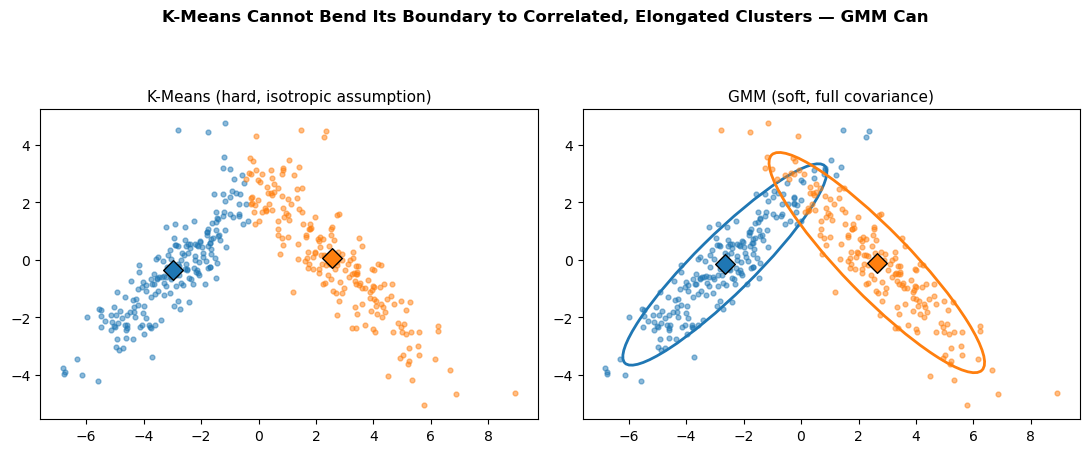

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def kmeans(X, K, n_iter, rng):
    N = X.shape[0]
    mu = X[rng.choice(N, K, replace=False)].copy()
    for _ in range(n_iter):
        dist2 = ((X[:, None, :] - mu[None, :, :]) ** 2).sum(axis=2)   # (N,K)
        assign = dist2.argmin(axis=1)
        for k in range(K):
            if np.any(assign == k):
                mu[k] = X[assign == k].mean(axis=0)
    return mu, assign

# Anisotropic (elongated / correlated) clusters: a case where the isotropic
# assumption behind K-means is expected to fail relative to full-covariance GMM.
rng = np.random.default_rng(11)
cov_aniso = np.array([[[3.0, 2.7], [2.7, 3.0]], [[3.0, -2.7], [-2.7, 3.0]]])
mu_aniso = np.array([[-2.5, 0.0], [2.5, 0.0]])
X_aniso, z_aniso = sample_gmm(400, [0.5, 0.5], mu_aniso, cov_aniso, rng)

mu_km, assign_km = kmeans(X_aniso, K=2, n_iter=20, rng=np.random.default_rng(11))
gmm_aniso = em_gmm(X_aniso, K=2, rng=np.random.default_rng(11))
hard_gmm = gmm_aniso["gamma"].argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, assign, mu_est, cov_est, title in [
    (axes[0], assign_km, mu_km, None, "K-Means (hard, isotropic assumption)"),
    (axes[1], hard_gmm, gmm_aniso["mu"], gmm_aniso["cov"], "GMM (soft, full covariance)"),
]:
    for k in range(2):
        ax.scatter(X_aniso[assign == k, 0], X_aniso[assign == k, 1], s=12, alpha=0.5, color=colors[k])
        ax.scatter(*mu_est[k], color=colors[k], edgecolor="black", marker="D", s=100, zorder=5)
        if cov_est is not None:
            ax.add_patch(cov_ellipse(mu_est[k], cov_est[k], n_std=2, fill=False, edgecolor=colors[k], lw=2))
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")
plt.suptitle("K-Means Cannot Bend Its Boundary to Correlated, Elongated Clusters — GMM Can", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 13. Model Selection: Choosing $K$ with AIC/BIC

The log-likelihood $\ell(\theta)$ can never *decrease* as $K$ grows (more components can only fit the data at least as well — in the limit $K=N$ each point gets its own component and $\ell\to\infty$, the degeneracy of Section 11). So $K$ cannot be chosen by maximizing $\ell$ alone; we need to penalize model complexity. Two standard information criteria (lower is better):

$$
\mathrm{AIC}=-2\hat\ell+2p,\qquad \mathrm{BIC}=-2\hat\ell+p\ln N,
$$

where $\hat\ell$ is the log-likelihood at convergence and $p$ is the number of **free** parameters of a $K$-component, $D$-dimensional, full-covariance GMM:

$$
p=\underbrace{(K-1)}_{\boldsymbol\pi\text{, minus the }\sum\pi_k=1\text{ constraint}}+\underbrace{K D}_{\text{means}}+\underbrace{K\frac{D(D+1)}{2}}_{\text{symmetric covariances}}.
$$

BIC penalizes complexity more heavily for large $N$ ($\ln N>2$ once $N>7$) and is the more common choice for selecting $K$ in a GMM.

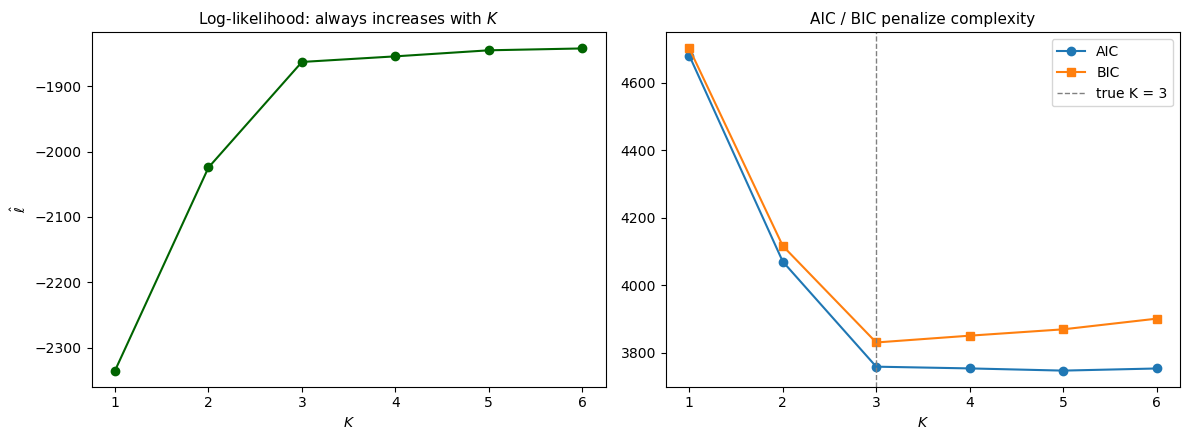

K minimizing BIC: 3  (data was generated with K=3)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def gmm_n_params(K, D):
    return (K - 1) + K * D + K * D * (D + 1) // 2

def aic_bic(X, K, n_restarts=5, n_iter=200):
    N, D = X.shape
    best_ll = -np.inf
    for r in range(n_restarts):
        res = em_gmm(X, K, n_iter=n_iter, rng=np.random.default_rng(100 + r))
        if res["history"][-1] > best_ll:
            best_ll = res["history"][-1]
    p = gmm_n_params(K, D)
    aic = -2 * best_ll + 2 * p
    bic = -2 * best_ll + p * np.log(N)
    return best_ll, aic, bic

Ks = range(1, 7)
lls, aics, bics = [], [], []
for K in Ks:
    ll, aic, bic = aic_bic(X, K)
    lls.append(ll); aics.append(aic); bics.append(bic)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(Ks), lls, marker="o", color="darkgreen")
axes[0].set_title("Log-likelihood: always increases with $K$", fontsize=11)
axes[0].set_xlabel("$K$"); axes[0].set_ylabel(r"$\hat\ell$")
axes[1].plot(list(Ks), aics, marker="o", label="AIC")
axes[1].plot(list(Ks), bics, marker="s", label="BIC")
axes[1].axvline(3, color="gray", ls="--", lw=1, label="true K = 3")
axes[1].set_title("AIC / BIC penalize complexity", fontsize=11)
axes[1].set_xlabel("$K$"); axes[1].legend()
plt.tight_layout()
plt.show()

print("K minimizing BIC:", list(Ks)[int(np.argmin(bics))], " (data was generated with K=3)")

---
## 14. Covariance Types & Applications

We close in three steps, all still built on nothing but `e_step`/`m_step` from Sections 7–8: (a) a self-consistency check — with $K=1$, EM has nothing to iterate on and must collapse to the closed-form single-Gaussian MLE of Section 2 in a single sweep; (b) restricting the shape of $\boldsymbol\Sigma_k$ (the `covariance_type` idea popularized by scikit-learn) to trade flexibility for fewer parameters; and (c) three applications a density model gives you for free that a hard clustering method (K-means) cannot: **density estimation**, **generative sampling**, and **anomaly detection**.

### Restricting the Covariance Shape

Instead of the unconstrained (`full`) $\boldsymbol\Sigma_k$ of Section 8, three cheaper variants are common — each obtained by projecting the full M-step estimate $\boldsymbol\Sigma_k^{\text{full}}$ onto a restricted family:

$$
\text{diag: keep only the diagonal}\qquad
\text{spherical: }\tfrac{\operatorname{tr}(\boldsymbol\Sigma_k^{\text{full}})}{D}\mathbf I\qquad
\text{tied: one shared }\boldsymbol\Sigma=\tfrac1N\sum_k N_k\boldsymbol\Sigma_k^{\text{full}}\text{ for every }k.
$$

Fewer parameters means faster fitting and less overfitting risk (recall $p$ from Section 13 scales with $D(D+1)/2$ per component for `full`, but only $D$, $1$, or a single shared block for `diag`, `spherical`, `tied`) — at the cost of forcing every cluster to look isotropic, axis-aligned, or identically-shaped.

In [11]:
import numpy as np

# Self-consistency check: with K=1 there is only one component, gamma is
# forced to be all-ones, and the M-step of Section 8 reduces exactly to the
# closed-form single-Gaussian MLE of Section 2.
result_k1 = em_gmm(X, K=1, rng=np.random.default_rng(0), n_iter=5)
mu_closed_form = X.mean(axis=0)
cov_closed_form = np.cov(X.T, bias=True)

print("mu  (EM, K=1):        ", np.round(result_k1["mu"][0], 4))
print("mu  (closed form, §2):", np.round(mu_closed_form, 4))
print("cov (EM, K=1):\n", np.round(result_k1["cov"][0], 4))
print("cov (closed form, §2):\n", np.round(cov_closed_form, 4))
print("\nmatch:", np.allclose(result_k1["mu"][0], mu_closed_form, atol=1e-3)
      and np.allclose(result_k1["cov"][0], cov_closed_form, atol=1e-2))

mu  (EM, K=1):         [-0.2339 -0.016 ]
mu  (closed form, §2): [-0.2339 -0.016 ]
cov (EM, K=1):
 [[6.3728 0.7186]
 [0.7186 6.2114]]
cov (closed form, §2):
 [[6.3728 0.7186]
 [0.7186 6.2114]]

match: True


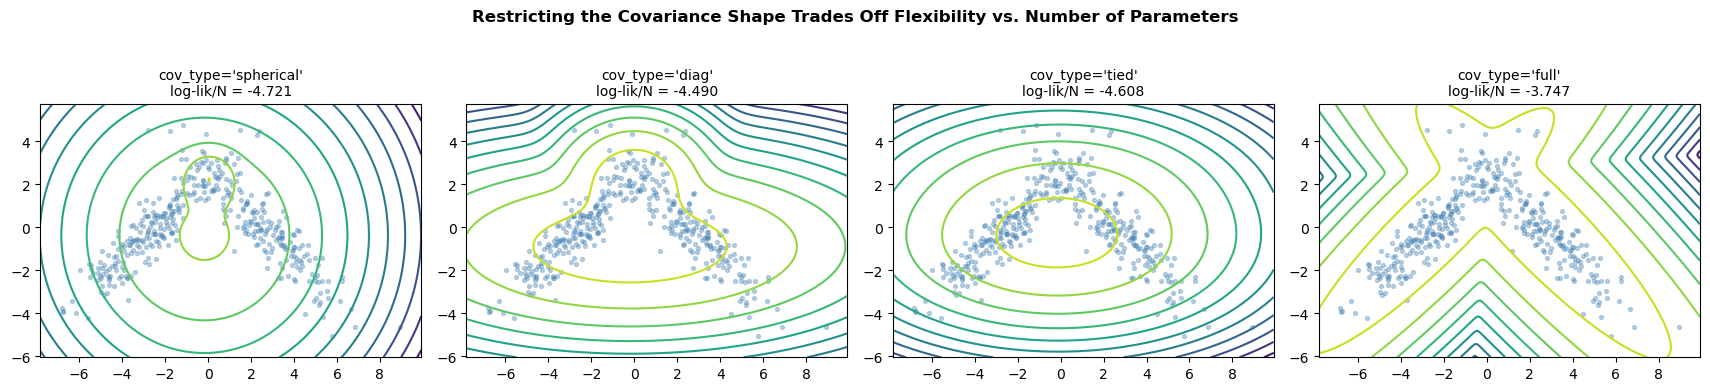

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def m_step_typed(X, gamma, cov_type, reg_covar=1e-6):
    # Same as m_step (Section 8), then projects the unconstrained ("full")
    # covariance onto the requested family.
    N, D = X.shape
    K = gamma.shape[1]
    Nk = gamma.sum(axis=0)
    pi = Nk / N
    mu = (gamma.T @ X) / Nk[:, None]
    cov_full = np.zeros((K, D, D))
    for k in range(K):
        diff = X - mu[k]
        weighted_diff = diff * gamma[:, k:k + 1]
        cov_full[k] = (weighted_diff.T @ diff) / Nk[k]

    if cov_type == "full":
        cov = cov_full
    elif cov_type == "diag":
        cov = np.array([np.diag(np.diag(c)) for c in cov_full])
    elif cov_type == "spherical":
        cov = np.array([(np.trace(c) / D) * np.eye(D) for c in cov_full])
    elif cov_type == "tied":
        shared = sum(Nk[k] * cov_full[k] for k in range(K)) / N
        cov = np.array([shared for _ in range(K)])
    else:
        raise ValueError(cov_type)

    cov = cov + reg_covar * np.eye(D)[None, :, :]
    return pi, mu, cov

def em_gmm_typed(X, K, cov_type, n_iter=100, tol=1e-6, reg_covar=1e-6, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    N, D = X.shape
    idx = rng.choice(N, size=K, replace=False)
    mu, cov, pi = X[idx].copy(), np.array([np.eye(D) for _ in range(K)]), np.full(K, 1.0 / K)
    history = []
    for it in range(n_iter):
        gamma, ll = e_step(X, pi, mu, cov)
        history.append(ll)
        pi, mu, cov = m_step_typed(X, gamma, cov_type, reg_covar=reg_covar)
        if it > 0 and abs(history[-1] - history[-2]) < tol:
            break
    gamma, ll = e_step(X, pi, mu, cov)
    history.append(ll)
    return {"pi": pi, "mu": mu, "cov": cov, "gamma": gamma, "history": np.array(history)}

cov_types = ["spherical", "diag", "tied", "full"]
fig, axes = plt.subplots(1, len(cov_types), figsize=(4.3 * len(cov_types), 4.3))
xx, yy = np.meshgrid(np.linspace(X_aniso[:, 0].min() - 1, X_aniso[:, 0].max() + 1, 150),
                      np.linspace(X_aniso[:, 1].min() - 1, X_aniso[:, 1].max() + 1, 150))
grid = np.column_stack([xx.ravel(), yy.ravel()])

for ax, ctype in zip(axes, cov_types):
    fit = em_gmm_typed(X_aniso, K=2, cov_type=ctype, rng=np.random.default_rng(0))
    zz = score_samples(grid, fit["pi"], fit["mu"], fit["cov"]).reshape(xx.shape)
    ax.scatter(X_aniso[:, 0], X_aniso[:, 1], s=8, alpha=0.35, color="steelblue")
    ax.contour(xx, yy, zz, levels=10, cmap="viridis")
    ll_per_point = fit["history"][-1] / len(X_aniso)
    ax.set_title(f"cov_type='{ctype}'\nlog-lik/N = {ll_per_point:.3f}", fontsize=10)
    ax.set_aspect("equal")
plt.suptitle("Restricting the Covariance Shape Trades Off Flexibility vs. Number of Parameters", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

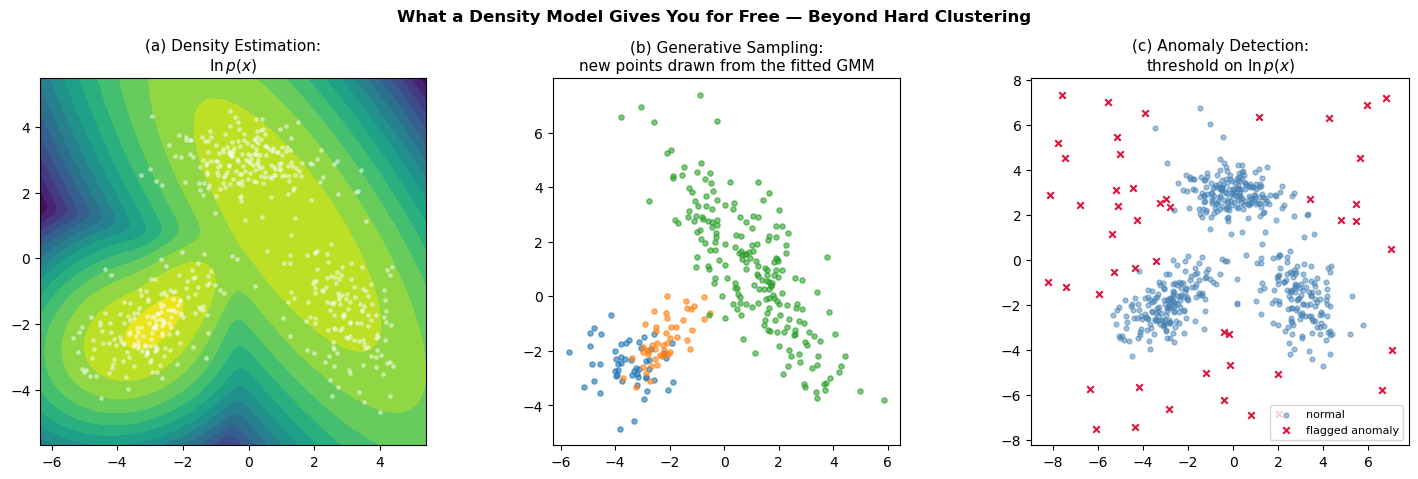

In [13]:
import numpy as np
import matplotlib.pyplot as plt

gmm_final = em_gmm(X, K=3, rng=np.random.default_rng(0), n_iter=200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# (a) Density estimation: contour of the fitted p(x), via score_samples (Section 7/14)
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
                      np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = score_samples(grid, gmm_final["pi"], gmm_final["mu"], gmm_final["cov"]).reshape(xx.shape)
axes[0].contourf(xx, yy, zz, levels=20, cmap="viridis")
axes[0].scatter(X[:, 0], X[:, 1], s=6, color="white", alpha=0.4)
axes[0].set_title("(a) Density Estimation:\n$\\ln p(x)$", fontsize=11)
axes[0].set_aspect("equal")

# (b) Generative sampling: draw brand-new points from the fitted GMM (Section 3's sample_gmm)
rng = np.random.default_rng(7)
X_sampled, z_sampled = sample_gmm(300, gmm_final["pi"], gmm_final["mu"], gmm_final["cov"], rng)
for k in range(3):
    axes[1].scatter(X_sampled[z_sampled == k, 0], X_sampled[z_sampled == k, 1], s=14, alpha=0.6, color=colors[k])
axes[1].set_title("(b) Generative Sampling:\nnew points drawn from the fitted GMM", fontsize=11)
axes[1].set_aspect("equal")

# (c) Anomaly detection: flag points with low log-density under the fitted model
X_outliers = rng.uniform(low=X.min(axis=0) - 3, high=X.max(axis=0) + 3, size=(60, 2))
X_test = np.vstack([X, X_outliers])
scores = score_samples(X_test, gmm_final["pi"], gmm_final["mu"], gmm_final["cov"])
threshold = np.percentile(score_samples(X, gmm_final["pi"], gmm_final["mu"], gmm_final["cov"]), 1)
is_anomaly = scores < threshold
axes[2].scatter(X_test[~is_anomaly, 0], X_test[~is_anomaly, 1], s=12, alpha=0.5, color="steelblue", label="normal")
axes[2].scatter(X_test[is_anomaly, 0], X_test[is_anomaly, 1], s=22, color="crimson", marker="x", label="flagged anomaly")
axes[2].set_title("(c) Anomaly Detection:\nthreshold on $\\ln p(x)$", fontsize=11)
axes[2].legend(fontsize=8)
axes[2].set_aspect("equal")

plt.suptitle("What a Density Model Gives You for Free — Beyond Hard Clustering", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Summary

| Concept | Key Formula | Core Insight |
|---------|-------------|---------------|
| GMM density | $p(\mathbf x)=\sum_k\pi_k\mathcal N(\mathbf x\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)$ | Universal density approximator; unimodal Gaussians combined |
| Latent variable | $p(\mathbf x)=\sum_z p(z)p(\mathbf x\mid z)$ | $z$ = unobserved cluster label; marginalizing recovers the mixture |
| Why MLE is hard | $\ell(\theta)=\sum_n\ln\sum_k\pi_k\mathcal N(\mathbf x_n\mid\cdot)$ | Log-of-sum couples all components; no closed form |
| ELBO / Jensen | $\ell(\theta)\ge\sum_i\sum_zQ_i(z)\ln\frac{p(\mathbf x^{(i)},z\mid\theta)}{Q_i(z)}$ | Tight iff $Q_i(z)=p(z\mid\mathbf x^{(i)},\theta)$ — the E-step |
| E-step (responsibility) | $\gamma_{nk}=\dfrac{\pi_k\mathcal N(\mathbf x_n\mid\boldsymbol\mu_k,\boldsymbol\Sigma_k)}{\sum_j\pi_j\mathcal N(\mathbf x_n\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)}$ | Soft posterior assignment via Bayes' rule |
| M-step | $\boldsymbol\mu_k=\frac{1}{N_k}\sum_n\gamma_{nk}\mathbf x_n$, $\boldsymbol\Sigma_k=\frac{1}{N_k}\sum_n\gamma_{nk}(\mathbf x_n-\boldsymbol\mu_k)(\cdot)^\top$, $\pi_k=N_k/N$ | Closed form *given* $\gamma$; weighted single-Gaussian MLE |
| Convergence | $\ell(\theta^{(t+1)})\ge\ell(\theta^{(t)})$ | ELBO sandwich argument; monotonic, only local optimum guaranteed |
| Singularities | $\boldsymbol\Sigma_k\to\mathbf 0\Rightarrow\ell\to\infty$ | Add $\varepsilon\mathbf I$ each M-step (regularized/MAP EM) |
| K-means limit | $\boldsymbol\Sigma_k=\varepsilon\mathbf I,\ \varepsilon\to0\Rightarrow\gamma_{nk}\to\mathbb 1[k{=}\arg\min_j\lVert\mathbf x_n-\boldsymbol\mu_j\rVert^2]$ | K-means = hard-EM, isotropic, tied, shrinking covariance |
| Model selection | $\mathrm{BIC}=-2\hat\ell+p\ln N$ | Penalizes the $K$ that always increases raw $\ell$ |

---

**Next →** `06_linear_regression.ipynb`: The Linear Model, the Residual Sum of Squares, and the Gauss-Markov Theorem.